# Constraint Satisfaction Problems (CSP)

Previously, we approached problem-solving through **state-space search**, where states were treated as atomic entities (**black boxes**) connected by actions. Domain-specific heuristics estimated the cost to reach the goal, but the internal structure of states remained unexamined. Now, we **open the black box** by representing each state as **a set of variables**. A problem is solved when all variables values satisfy their constraints, defining a **constraint satisfaction problem (CSP)**. This structured representation allows for more **efficient search algorithms** that exploit the problem’s constraints to **prune large sections of the search space**, eliminating invalid variable-value combinations. However, this specialization may limit the range of problems we can address. Why do we search? One approach is **planning**, which focuses on finding sequences of actions to reach a goal (e.g., navigation, 8-puzzle), where the path, cost, and depth matter, often guided by heuristics. Alternatively, we might focus on **identification**, which involves assigning values to variables (e.g., 8-Queens problem), where the goal itself is key rather than the path, with all solutions potentially at the same depth. CSPs are a specialized subset of **identification problems**, leveraging constraints to streamline the search process.

## Formal definition

A CPS consists of **a set of variables**:

$\displaystyle X = \{X_1, X_2, ... ,X_n\}$

A **set of domains**: 

$\displaystyle D = \{D_1, D_2, ... ,D_n\}$

one for each variable. Each domain consists of **a set of allowable values**: 

$\displaystyle D_i = \{v_1, v_2, ... ,v_k\}$

For example, a boolean variable would have the domain (true, false). Different variables can have different domains of different sizes. The simplest kind of CSP involves variables that have **discrete, finite domains**. A discrete domain can also be **infinite**. Problems with **continuous domains** are common in the real world. 

Finally a **set of constraints**: 

$\displaystyle C = \{C_1, C_2, ... ,C_m\}$ 

that specify **allowable combinations of values**.

### Constraints

A constraint consists of a pair:

$\displaystyle C_j = <\text{scope}, \quad \text{relation}>$

where the **scope** is a tuple of variables that participate in the constraint and the **relation** defines the values that those variables can take on. A relation can be represented as **an explicit set of all tuples of values** that satisfy the constraint, or as **a function** that can compute whether a tuple is a member of the relation.  The simplest type is the **unary constraint**, which restricts the value of a single variable. A **binary constraint** relates two variables. For example, if we have two variables:

$\displaystyle X_1,  X_2$ 

both having the domain: 

$\displaystyle D_{1,2} = \{1,2,3\}$ 

then the binay constraint saying that the first variable must be greater than the second can be written as:

$\displaystyle C = <(X_1, X_2), \quad \{(3,1),(3,2),(2,1)\}>$

or using a function as:

$\displaystyle C = <(X_1, X_2), \quad X_1 > X_2 >$

A **binary CSP** is one with only unary and binary constraints. However, we can also define **higher-order constraints**. As an example the ternary constraint:

$\displaystyle C = <(X_1, X_2, X_3), \quad X_1 < X_2 < X_3 \quad \text{or} \quad X_1 > X_2 > X_3 >$

The constraint ensures that the three variables form either a strictly increasing or strictly decreasing sequence. A **global constraint** involves multiple variables, though not necessarily all in the problem. A key example is **Alldiff**, which enforces that all variables in the constraint take distinct values:

$\displaystyle C = <(X_1, X_2, ... , X_n), \quad X_1 \neq X_2 \neq ... \neq X_n >$

Constraints can be **absolute** (strictly enforcing feasibility) or **preference-based** (indicating **desirable solutions**). In real-world problems like university scheduling, absolute constraints prevent conflicts (e.g., a professor cannot teach two classes at the same time), while preference constraints express priorities (e.g., Prof. X prefers morning classes). A schedule violating a preference remains valid but may be suboptimal. Preferences are often **modeled as costs** on variable assignments, such as assigning an afternoon slot to X incurring a penalty of 2, while a morning slot incurs a penalty of 1.

### Assignment

We define an **assignment** as the definition of a specific value to some variable:

$\displaystyle A = \{ X_i = v_i, X_j=v_j, ...\}$

An assignment in which all variable is assigned a value is called a **complete** and if it does **not violate any constraints** is called **consistent**. A complete and consistent assignemetn is a **solution** of the CSP. A **partial assignment** is one that leaves some variables unassigned, and a **partial solution** is a partial assignment that is consistent. Solving a CSP is **an NP-complete problem** in general, although there are important subclasses of problems that can be solved efficiently.

### Hypergraph

Constraints can be represented in a **constraint hypergraph**, which consists of ordinary **nodes** (the circles in the following figure) and **hypernodes** (the squares), which represent constraints involving variables:

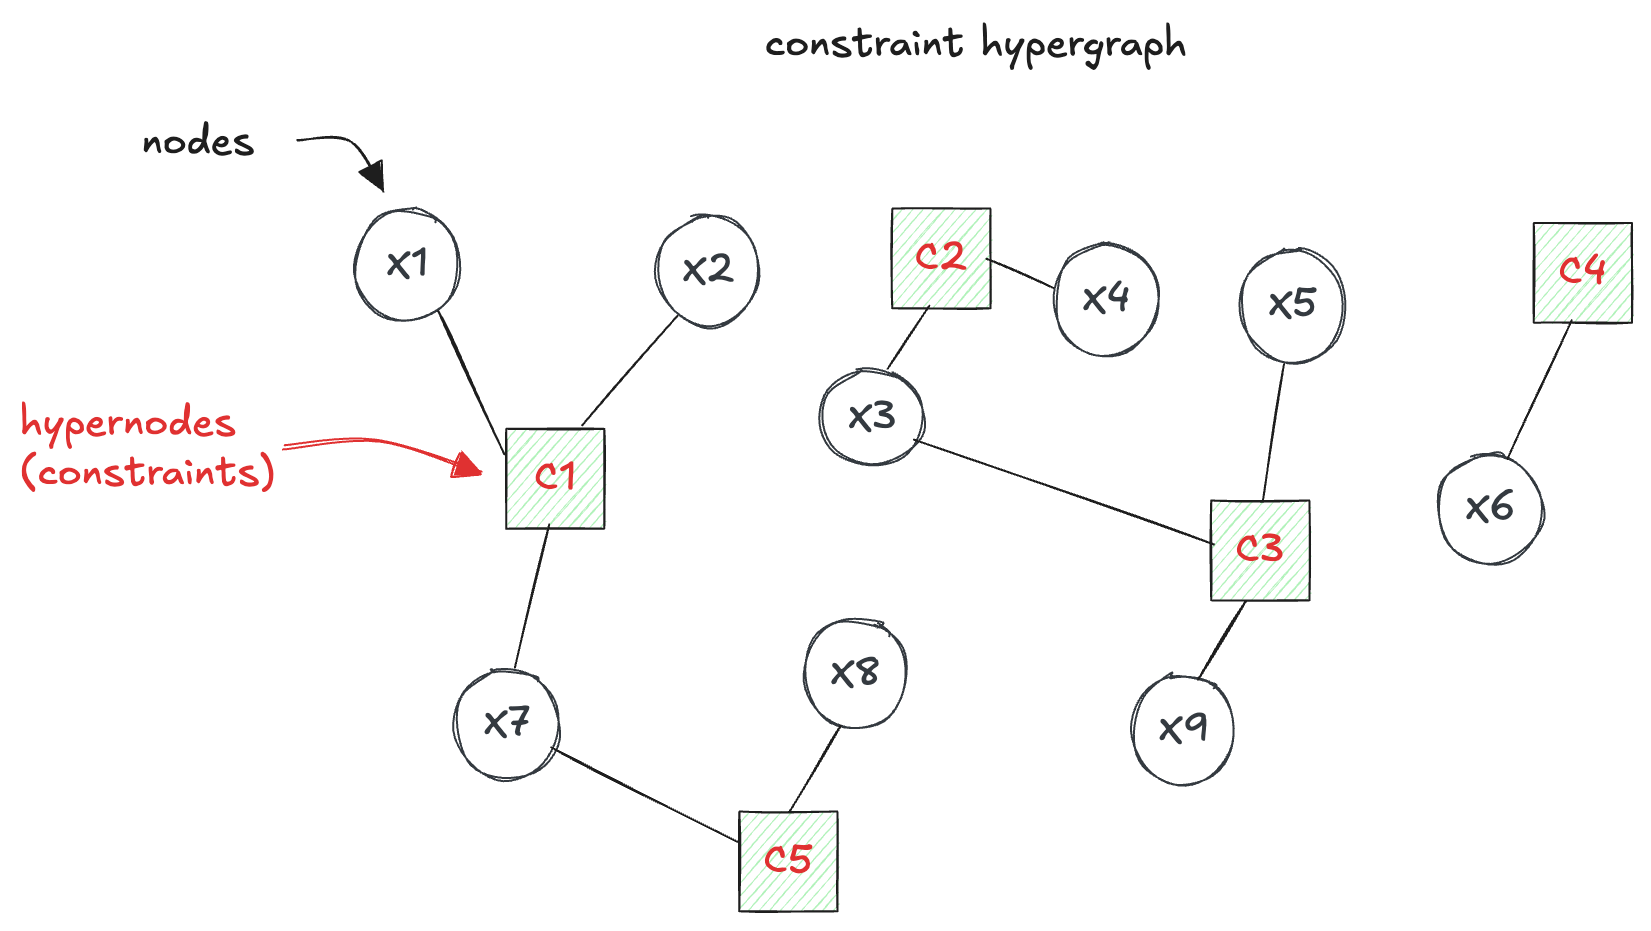

## Reduction to binary problem

Every n-ary finite-domain constraint can be **reduced into a set of binary constraints** by introducing **auxiliary variables**, which are additional variables that are not part of the original problem, but encapsulate the relationships among constrained variables. Each auxiliary variable is assigned a **domain that corresponds to the Cartesian product** of the domains of the individual variables it represents and the original n-ary constraint as unary constraint on the auxiliary variable. 
For example, consider the following original variables and their domains:

$\displaystyle X, \quad D_x= \{1,2\} $

$\displaystyle Y, \quad D_y= \{3,4\} $

$\displaystyle Z, \quad D_z= \{5,6\} $

and suppose to have the following constraints:

$\displaystyle C1 = <(X,Y,Z), \quad X+Y=Z>$

$\displaystyle C2 = <(X,Y), \quad X<Y>$

We can create an auxiliary variable U with the domain:

$\displaystyle U, \quad D_u = \{(1,3,5), (1,3,6), (1,4,5), (1,4,6), (2,3,5), (2,3,6), (2,4,5), (2,4,6) \}$

Now, The n-ary constraint can be replaced by restricting the domain of the auxiliary variable and adding binary constraints:

$\displaystyle U, \quad D_u = \{(1,4,5), (2,3,5), (2,4,6)\}$

$\displaystyle C3 = <(X,U), \quad X=U[0]>$

$\displaystyle C4 = <(Y,U), \quad Y=U[1]>$

$\displaystyle C5 = <(Z,U), \quad Z=U[2]>$

Another way to convert an n-ary CPS to a binary one is the **dual graph transformation**: create a new graph in which there will be one variable for each constraint in the original graph, and one binary constraint for each pair of constraints in the original graph that share variables. In the example above, we need to creare another auxiliary variable for the other constraint:

$\displaystyle V, \quad D_v = \{(1,3), (1,4), (2,3), (2,4)\}$

in this case, we don't need to limit the domain of the auxiliary variable, because all configuration are valid. Finally, we need to add two binary constraints becouse the two constraints in the original graph share two variables:

$\displaystyle C6 = <(U,V), \quad U[0]=V[0]>$

$\displaystyle C7 = <(U,V), \quad U[1]=V[1]>$

The resulting constraint network is more compact than the one from the previous method. However, extracting the solution (i.e., the assignment of the original variables) requires interpreting the values of the auxiliary variables.

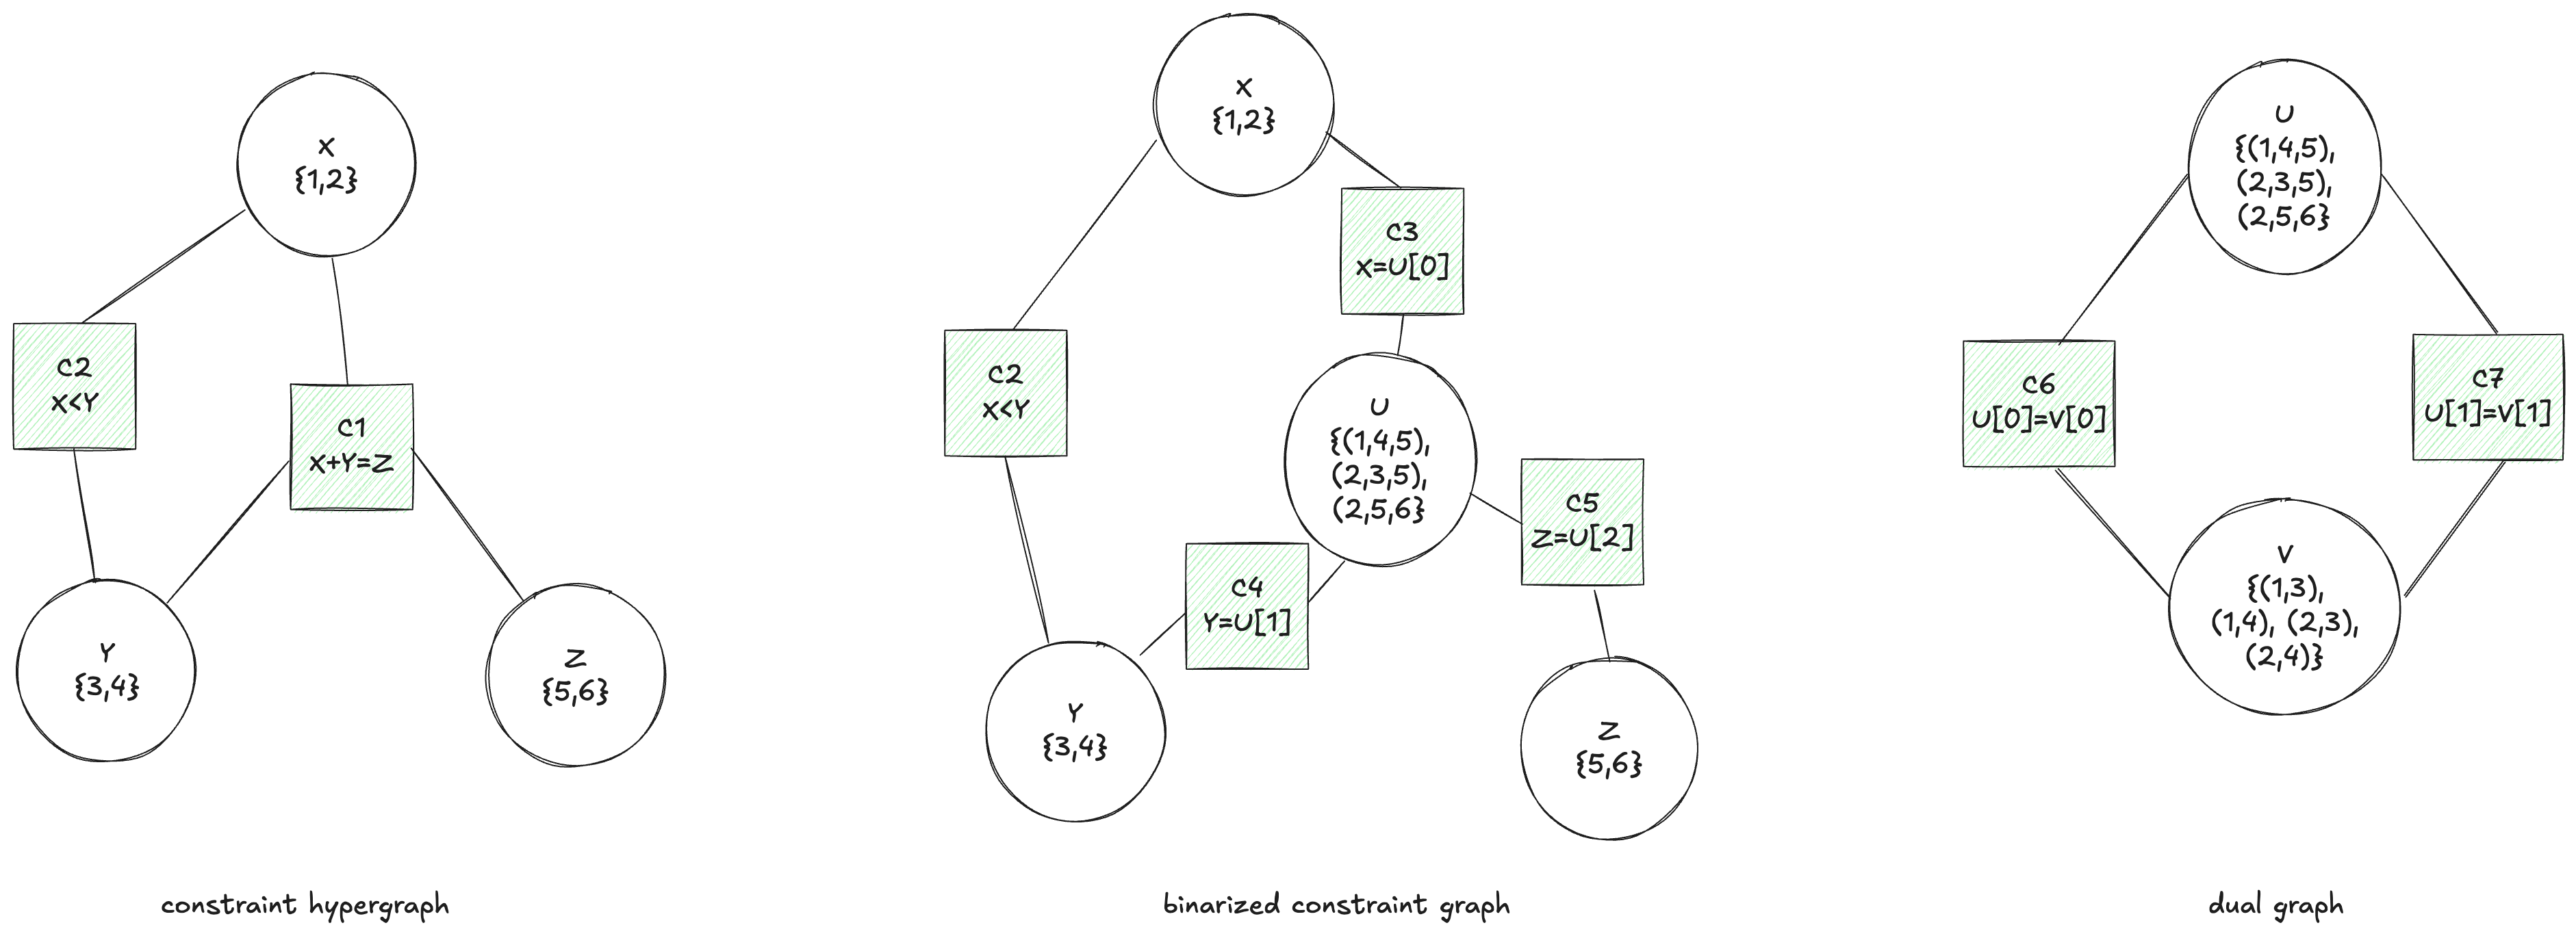

Expressing n-ary constraints as binary constraints is theoretically significant, as it allows us to generalize all CSPs as binary CSPs. However, in practice, this transformation is often impractical and inefficient. The use of n-ary constraints simplifies problem formulation and allows for specialized inference algorithms that are more efficient than handling multiple primitive constraints.

## Implementation 

We can implement in Python a class to descrive finite-domain binary CSP problem. In particular, we formulate the constraints providing a dict of neighbors for each variable that lists the other variables that participate in constraints and a function that returns true if two neighbors satisfy a constraint when they have specific values.

In [97]:
class CSP():

    def __init__(self, variables, domains, neighbors, constraints, assignment):
        variables = variables or list(domains.keys())
        self.variables = variables
        self.domains = domains
        self.neighbors = neighbors
        self.constraints = constraints
        self.assignment = assignment
 
    # Assign a value to a variable
    def assign(self, var, val):
        self.assignment[var] = val

    # Unassign a variable
    def unassign(self, var):
        if var in self.assignment:
            del self.assignment[var]

    # Check if a value for a variable conflicts with another variable
    def conflict(self, var, val, other):
        return other in self.assignment and not self.constraints(var, val, other, self.assignment[other])

    # Check if a value for a variable conflicts
    def count_conflicts(self, var, val):
        return sum(map(bool, (self.conflict(var, val, other) for other in self.neighbors[var])))

    # Print the problem
    def print(self, v=False, d=False, n=False, a=False):
        if v: 
            print("Variables:", self.variables)
        if d:
            print("Domains:")
            for key, value in self.domains.items():
                print(f"\t{key}: {value}")
        if n:
            print("Neighbors:")
            for key, value in self.neighbors.items():
                print(f"\t{key}: {value}")
        if a:
            print("Assignment:", self.assignment)

## Problem examples

To illustrate the practical relevance of CSPs, we explore several classic examples that showcase different types of constraints and solution strategies.

### Map coloring

Imagine we have a map of a country, like Australia, with its different territories. The challenge is to color each region using red, green, or blue while making sure that no two neighboring regions share the same color. This setup naturally fits into the framework of a CSP. A great way to visualize it is through a **constraint graph**. In this graph, each region is represented as a node and an edge connects any two nodes that must follow a constraint (in this case, ensuring they have different colors). In this simple example, there is no need to represent hyper nodes (which is useful for higher-order constraints). The simple pairwise constraints between neighboring regions are enough to capture the problem, so the graph only shows regular nodes and edges. The absence of hypernodes doesn't impact the formulation, as the constraints only involve pairs of adjacent regions, which makes it a simple graph-based CSP rather than one requiring hypergraphs. Thus, by visualizing the problem in this way, we can approach it using standard CSP-solving techniques like backtracking or constraint propagation, keeping track of the constraints that adjacent regions cannot share the same color.

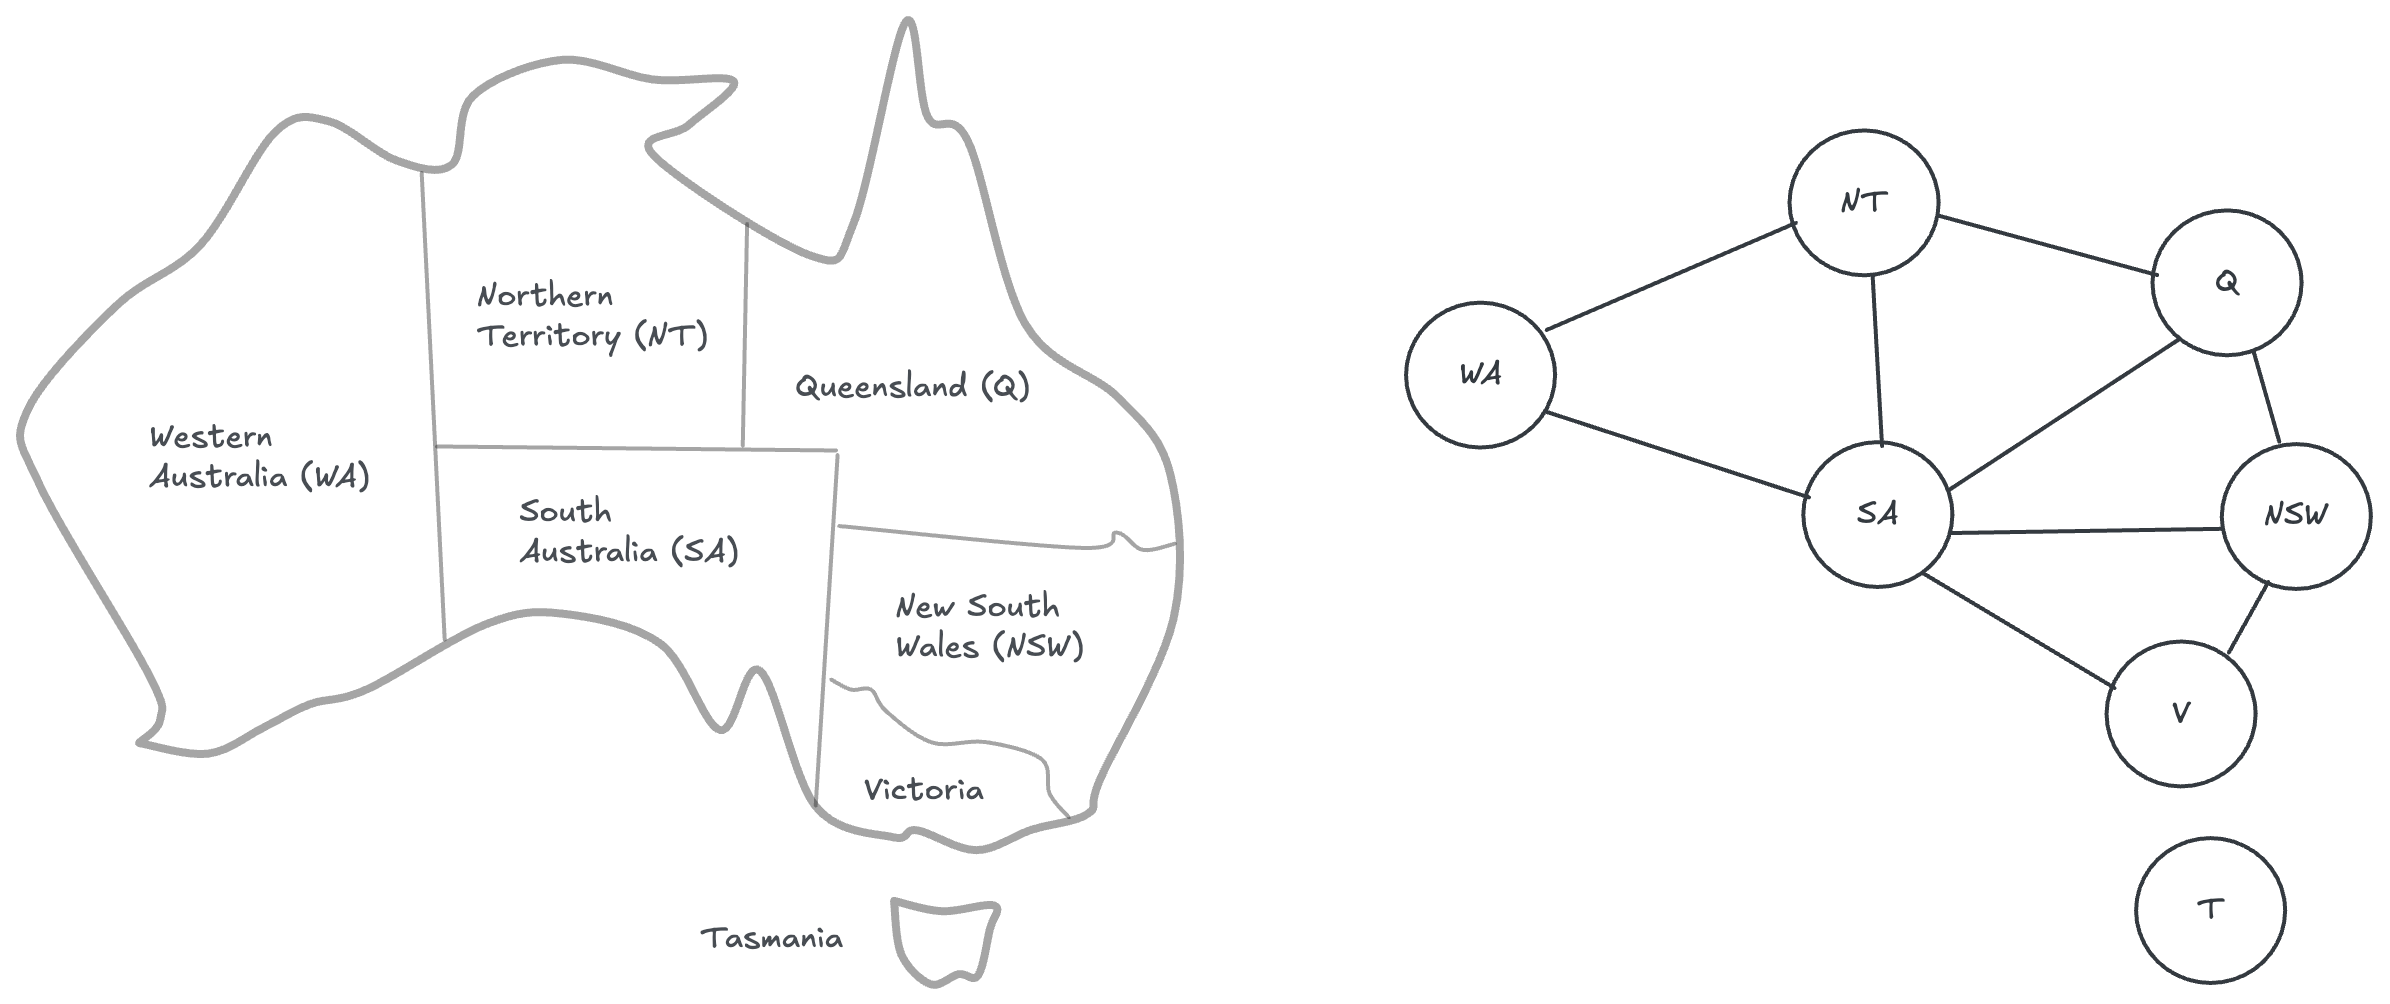

We define the variables to be the regions:

$\displaystyle X = \{\text{WA}, \text{NT}, \text{Q}, \text{NSW}, \text{V}, \text{SA}, \text{T}\}$

In [98]:
variables = ['WA', 'NT', 'Q', 'NSW', 'V', 'SA', 'T']

The domain of every variable is the set of possible colors:

$\displaystyle D_i = \{\text{red}, \text{green}, \text{blue}\}$

In [99]:
domains = {
    'WA' : ['r', 'g', 'b'],
    'NT' : ['r', 'g', 'b'],
    'Q' : ['r', 'g', 'b'],
    'NSW' : ['r', 'g', 'b'],
    'V' : ['r', 'g', 'b'],
    'SA' : ['r', 'g', 'b'],
    'T' : ['r', 'g', 'b']
}

The constraints ensure neighboring regions have distinct colors, resulting in nine constraints (one for each border between regions):
    
$\displaystyle C = \{  \\
\quad < (\text{SA}, \text{WA}),  \text{SA}  \neq \text{SA} >, \\
\quad < (\text{SA},  \text{NT}), \text{SA}  \neq \text{SA} >, \\
\quad < (\text{SA}, \text{Q}),   \text{SA}  \neq \text{SA} >, \\
\quad < (\text{SA}, \text{NSW}), \text{SA}  \neq \text{SA} >, \\
\quad < (\text{SA}, \text{V}),   \text{SA}  \neq \text{SA} >, \\
\quad < (\text{WA}, \text{NT}),  \text{WA}  \neq \text{SA} >, \\
\quad < (\text{NT}, \text{Q}),   \text{NT}  \neq \text{SA} >, \\
\quad < (\text{Q}, \text{NSW}),  \text{Q}   \neq \text{SA} >, \\  
\quad < (\text{NSW}, \text{V}),  \text{NSW} \neq \text{SA} >  \\
\}$

In Python we explicitate the constrains using the neighbors specification and the function that checks that the colors are different:

In [100]:
neighbors = {
    'WA': ['NT', 'SA'],
    'NT': ['WA', 'SA', 'Q'],
    'SA': ['WA', 'NT', 'Q', 'NSW', 'V'],
    'Q': ['NT', 'SA', 'NSW'],
    'NSW': ['Q', 'SA', 'V'],
    'V': ['SA', 'NSW'],
    'T': []
}

def color_constraint(var_1, val_1, var_2, val_2):
    return val_1 != val_2

A possibile solution is expresees from the following assignment:

In [101]:
assignment = { 'WA': 'r', 'NT': 'g', 'Q': 'b', 'NSW': 'r', 'V': 'g', 'SA': 'b', 'T': 'r' }

We can now create the CSP object:

In [102]:
australia = CSP(variables, domains, neighbors, color_constraint, assignment)

And check some conflicts:

In [103]:
print("Number of conflicts of WA = b:", australia.count_conflicts('WA', 'b'))
    

Number of conflicts of WA = b: 1


We can show the complete information about the CSP:

In [104]:
australia.print(v=True, d=True, n=True, a=True)

Variables: ['WA', 'NT', 'Q', 'NSW', 'V', 'SA', 'T']
Domains:
	WA: ['r', 'g', 'b']
	NT: ['r', 'g', 'b']
	Q: ['r', 'g', 'b']
	NSW: ['r', 'g', 'b']
	V: ['r', 'g', 'b']
	SA: ['r', 'g', 'b']
	T: ['r', 'g', 'b']
Neighbors:
	WA: ['NT', 'SA']
	NT: ['WA', 'SA', 'Q']
	SA: ['WA', 'NT', 'Q', 'NSW', 'V']
	Q: ['NT', 'SA', 'NSW']
	NSW: ['Q', 'SA', 'V']
	V: ['SA', 'NSW']
	T: []
Assignment: {'WA': 'r', 'NT': 'g', 'Q': 'b', 'NSW': 'r', 'V': 'g', 'SA': 'b', 'T': 'r'}


### Job scheduling

Factories must schedule daily jobs while satisfying various constraints. Consider assembling a car: each task is a variable, with its value representing the start time in minutes. Constraints enforce task order (e.g., wheels before hubcaps), limit concurrent tasks, and define task durations. A simplified case involves several tasks: installing axles, attaching and securing wheels with nuts, affixing hubcaps, and inspecting the assembly:

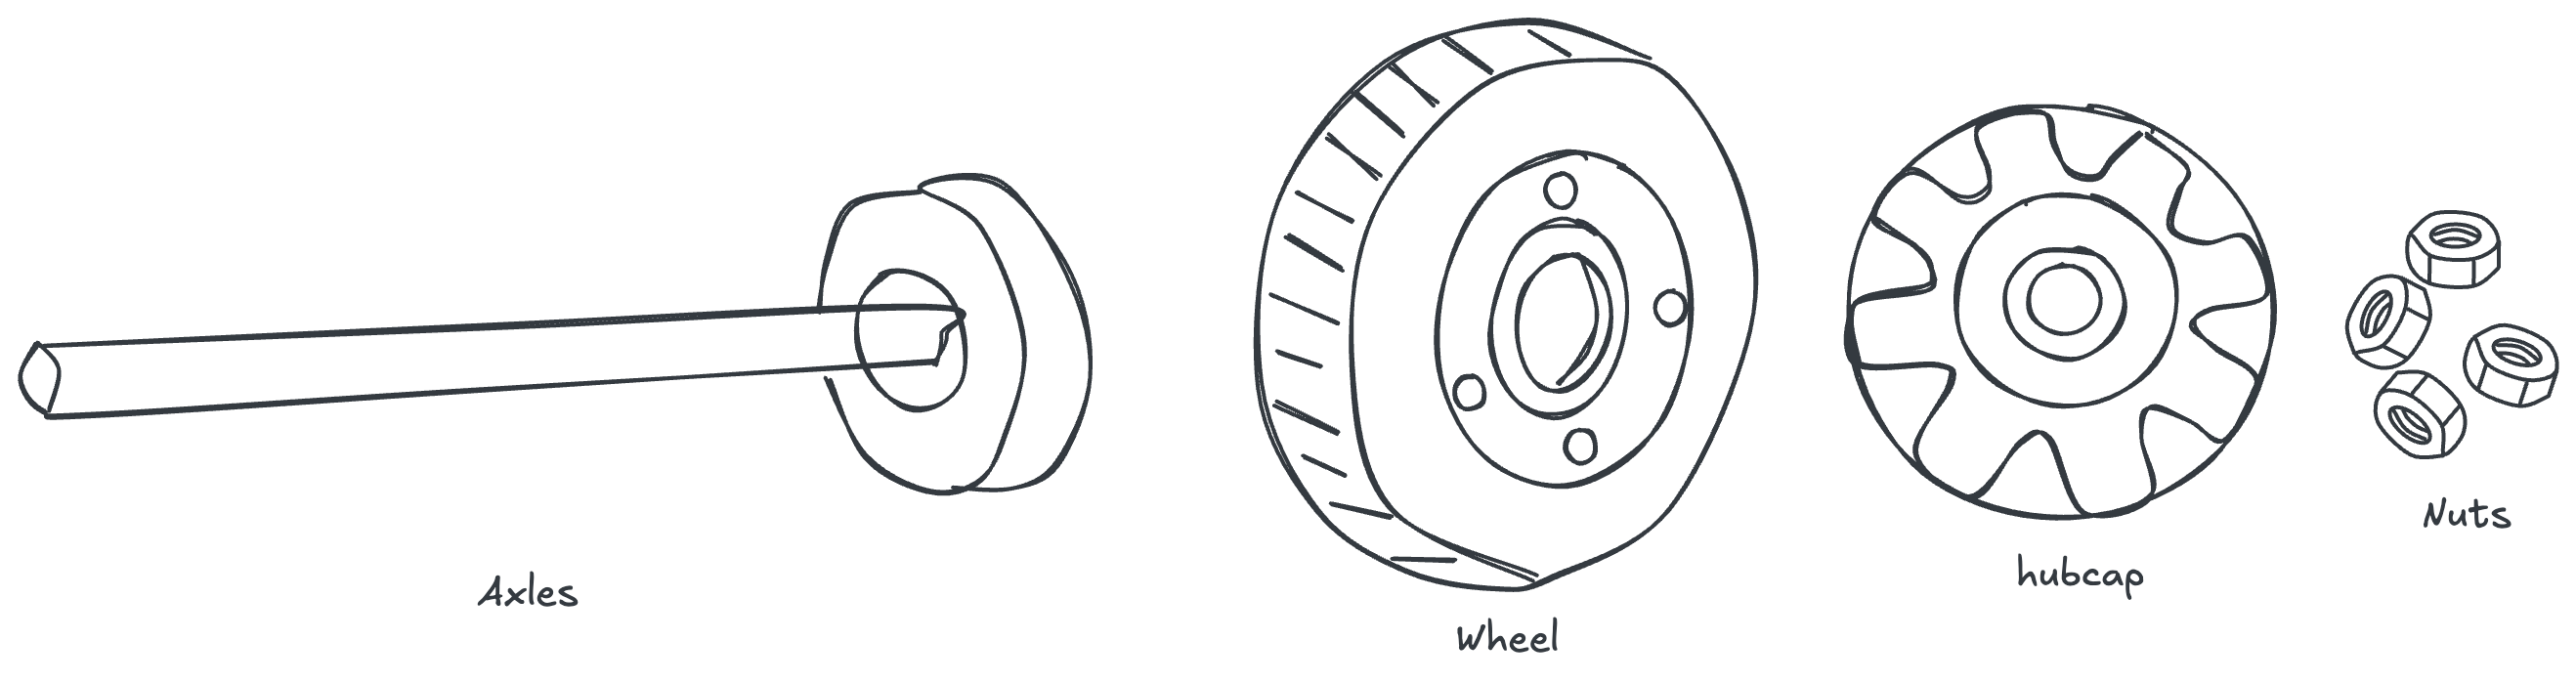

These tasks can be represented as variables:

$\displaystyle X = \{ \\
\quad \text{Axle}_F, \text{Axle}_B, \\ 
\quad \text{Wheel}_{RF}, \text{Wheel}_{LF}, \text{Wheel}_{RB}, \text{Wheel}_{LB}, \\
\quad \text{Nut}_{RF}, \text{Nut}_{LF}, \quad \text{Nut}_{RB}, \text{Nut}_{LB}, \\
\quad \text{Hubcap}_{RF}, \text{Hubcap}_{LF}, \quad \text{Hubcap}_{RB}, \text{Hubcap}_{LB}, \\
\quad \text{Inspect} \\
\}$

We need to represent precedence constraints between individual tasks. Whenever a task T1 with duration d1 must occur before task T2, we can write an **arithmetic constraint** on the form:

$\displaystyle T1 + d1 \leq T2$

In our example, the axles have to be in place before the wheels are put on, and it takes 10 minutes to install an axle, so we can write:

$\displaystyle \text{Axle}_F + 10 \leq \text{Wheel}_{RF}$

$\displaystyle \text{Axle}_F + 10 \leq \text{Wheel}_{LF}$

$\displaystyle \text{Axle}_B + 10 \leq \text{Wheel}_{RB}$

$\displaystyle \text{Axle}_B + 10 \leq \text{Wheel}_{LB}$

For each wheel, we must affix the wheel (which takes 1 minute), then tighten
the nuts (2 minutes), and finally attach the hubcap (1 minute):

$\displaystyle \text{Wheel}_{RF} + 1 \leq \text{Nut}_{RF}$

$\displaystyle \text{Nut}_{RF} + 2 \leq \text{Hubcap}_{RF}$

$\displaystyle \text{Wheel}_{LF} + 1 \leq \text{Nut}_{LF}$

$\displaystyle \text{Nut}_{LF} + 2 \leq \text{Hubcap}_{LF}$

$\displaystyle \text{Wheel}_{RB} + 1 \leq \text{Nut}_{RB}$

$\displaystyle \text{Nut}_{RB} + 2 \leq \text{Hubcap}_{RB}$

$\displaystyle \text{Wheel}_{LB} + 1 \leq \text{Nut}_{LB}$

$\displaystyle \text{Nut}_{LB} + 2 \leq \text{Hubcap}_{LB}$

Suppose We have four workers to install wheels, but they have to share one tool that helps put the axle in place. We need a **disjunctive constraint** to say that AxleF and AxleB must not overlap in time:

$\displaystyle \text{Axle}_F + 10 \leq \text{Axle}_B \quad \text{or} \quad \text{Axle}_B + 10 \leq \text{Axle}_F$

Finally, the inspection task can only start after all other tasks are completed and takes 3 minutes. For every variable X, we can write:

$\displaystyle X + d_X \leq \text{Inspect}$

Finally, suppose we have a requirement that the whole process must be completed in 30 minutes. We can achieve that by limiting the domain of all variables:

$\displaystyle D_i = \{0, 1, 2, ..., 30\}$

This particular problem is trivial to solve, but CSPs have been successfully applied to job scheduling problems with thousands of variables.

### Eight-queens puzzle

The 8-queens problem can also be viewed as a CSP, where the variable correspond
to the queens in columns 1 to 8:

$\displaystyle X = \{Q_1, Q_2, Q_3, Q_4, Q_5, Q_6, Q_7, Q_8\}$

the domain of each variable specifies the possible row numbers for the queen in that column

$\displaystyle D_i = \{1,2,3,4,5,6,7,8\}$

The constraints say that no two queens can be in the same column (implicitly encoded in the representation, since we do not allow two queens in the same column) or in the same row:

$\displaystyle C = \{ <(Q_i, Q_j), \; Q_i \neq Q_j> \; \text{for all} \; i, j \in \{1,2,3,4,5,6,7,8\} \; \text{and} \; i \neq j \}$

or in the same diagonal:

$\displaystyle C = \{ <(Q_i, Q_j), \; |Q_i - Q_j| \neq |i-j| > \; \text{for all} \; i, j \in \{1,2,3,4,5,6,7,8\} \; \text{and} \; i \neq j \}$

The difference in column positions must not equal the difference in row positions, preventing them from being on the same diagonal.

### Cryptarithmetic puzzle

A cryptarithmetic puzzle is a mathematical puzzle where each letter or symbol represents a unique digit, and the goal is to find the correct digits that satisfy a given arithmetic equation, with the added restriction that no leading zeroes are allowed and two different letters cannot represent the same digit. Considering the following example: 

T W O + 

T W O = 

F O U R

The problem can be represented using a global constraint to ensure that each letter is assigned a different digit:

$\displaystyle \text{Alldiff}(\text{F}, \text{T}, \text{U}, \text{W}, \text{R}, \text{O})$

The addition constraints on the four columns of the puzzle can be written as the following n-ary constraints:

$\displaystyle \text{O} + \text{O} = \text{R} + 10 \times \text{C}_1$

$\displaystyle \text{C}_1 + \text{W} + \text{W} = \text{U} + 10 \times \text{C}_2$

$\displaystyle \text{C}_2 + \text{T} + \text{T} = \text{O} + 10 \times \text{C}_3$

$\displaystyle \text{C}_3 = \text{F}$

where C1, C2, and C3 are **auxiliary variables** representing digits carried over into the tens, hundreds, or thousands column. These constraints can be represented using a constraint hypergraph:

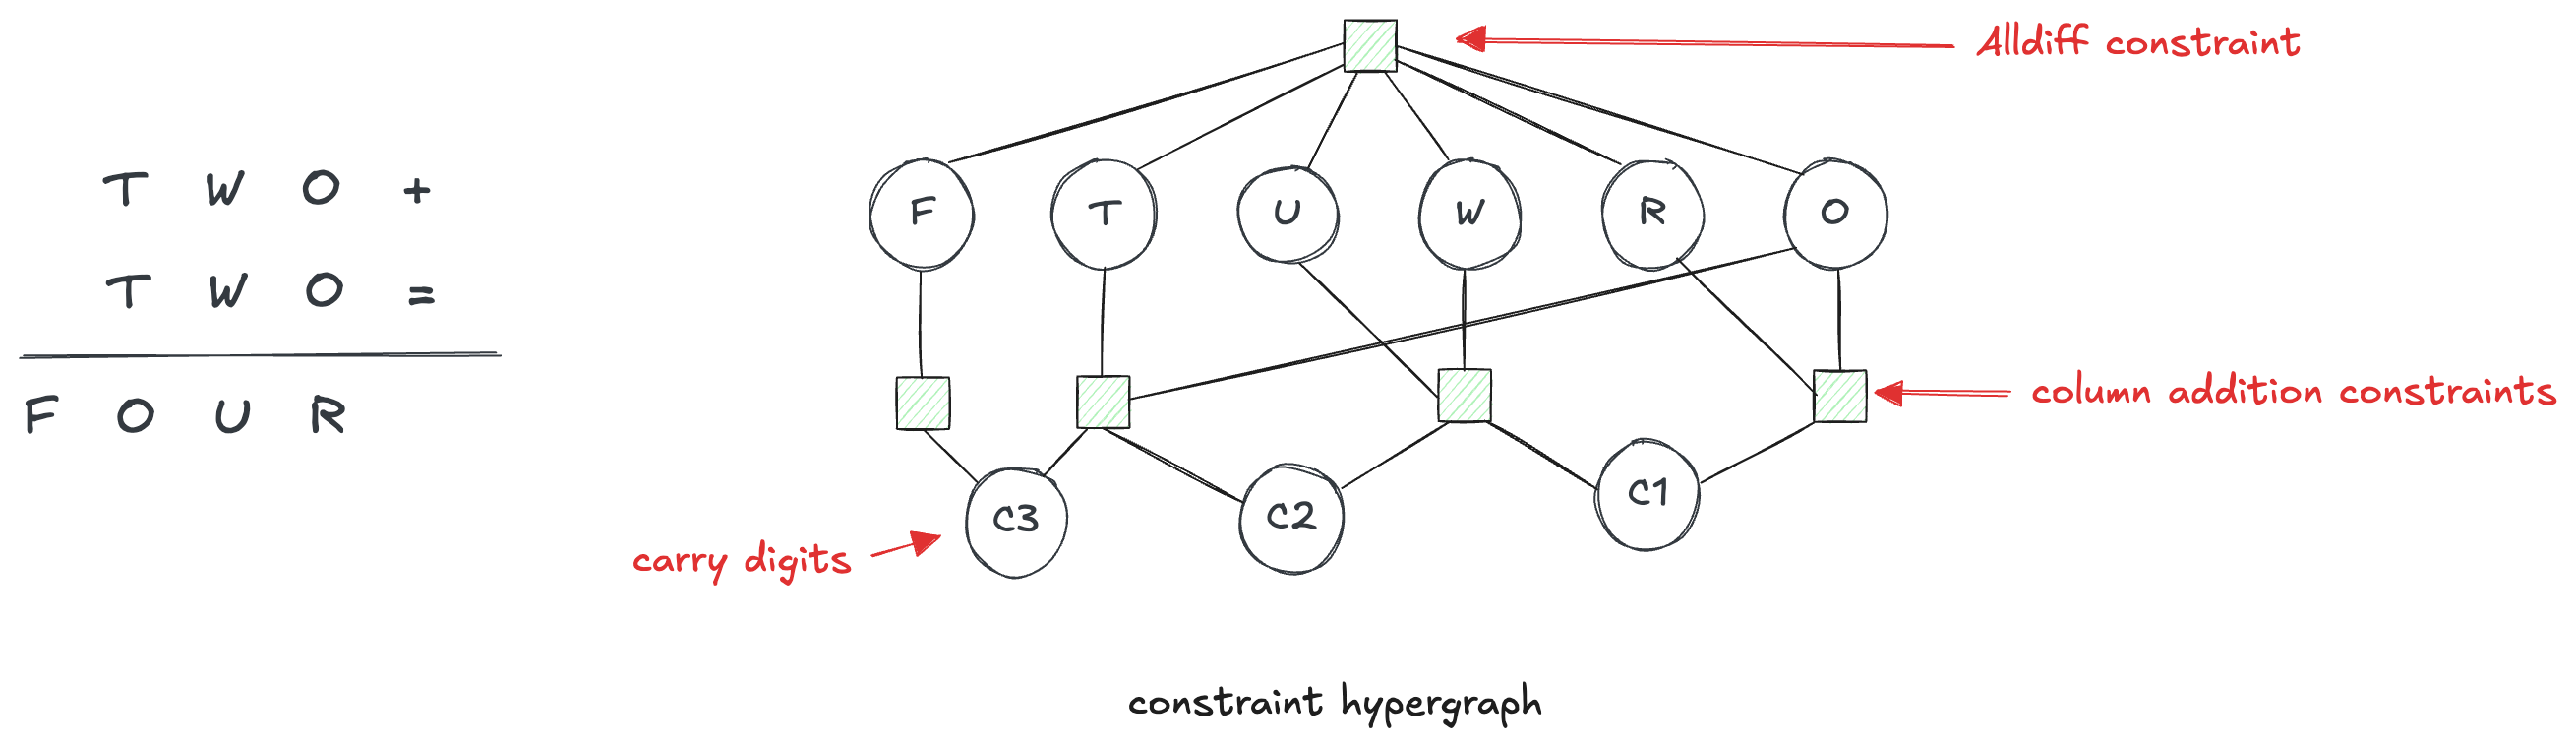


### Sudoku

A Sudoku board consists of 81 squares, some of which are initially filled with digits from 1 to 9. The puzzle is to fill in all the remaining squares such that no digit appears twice in any row, column, or box:

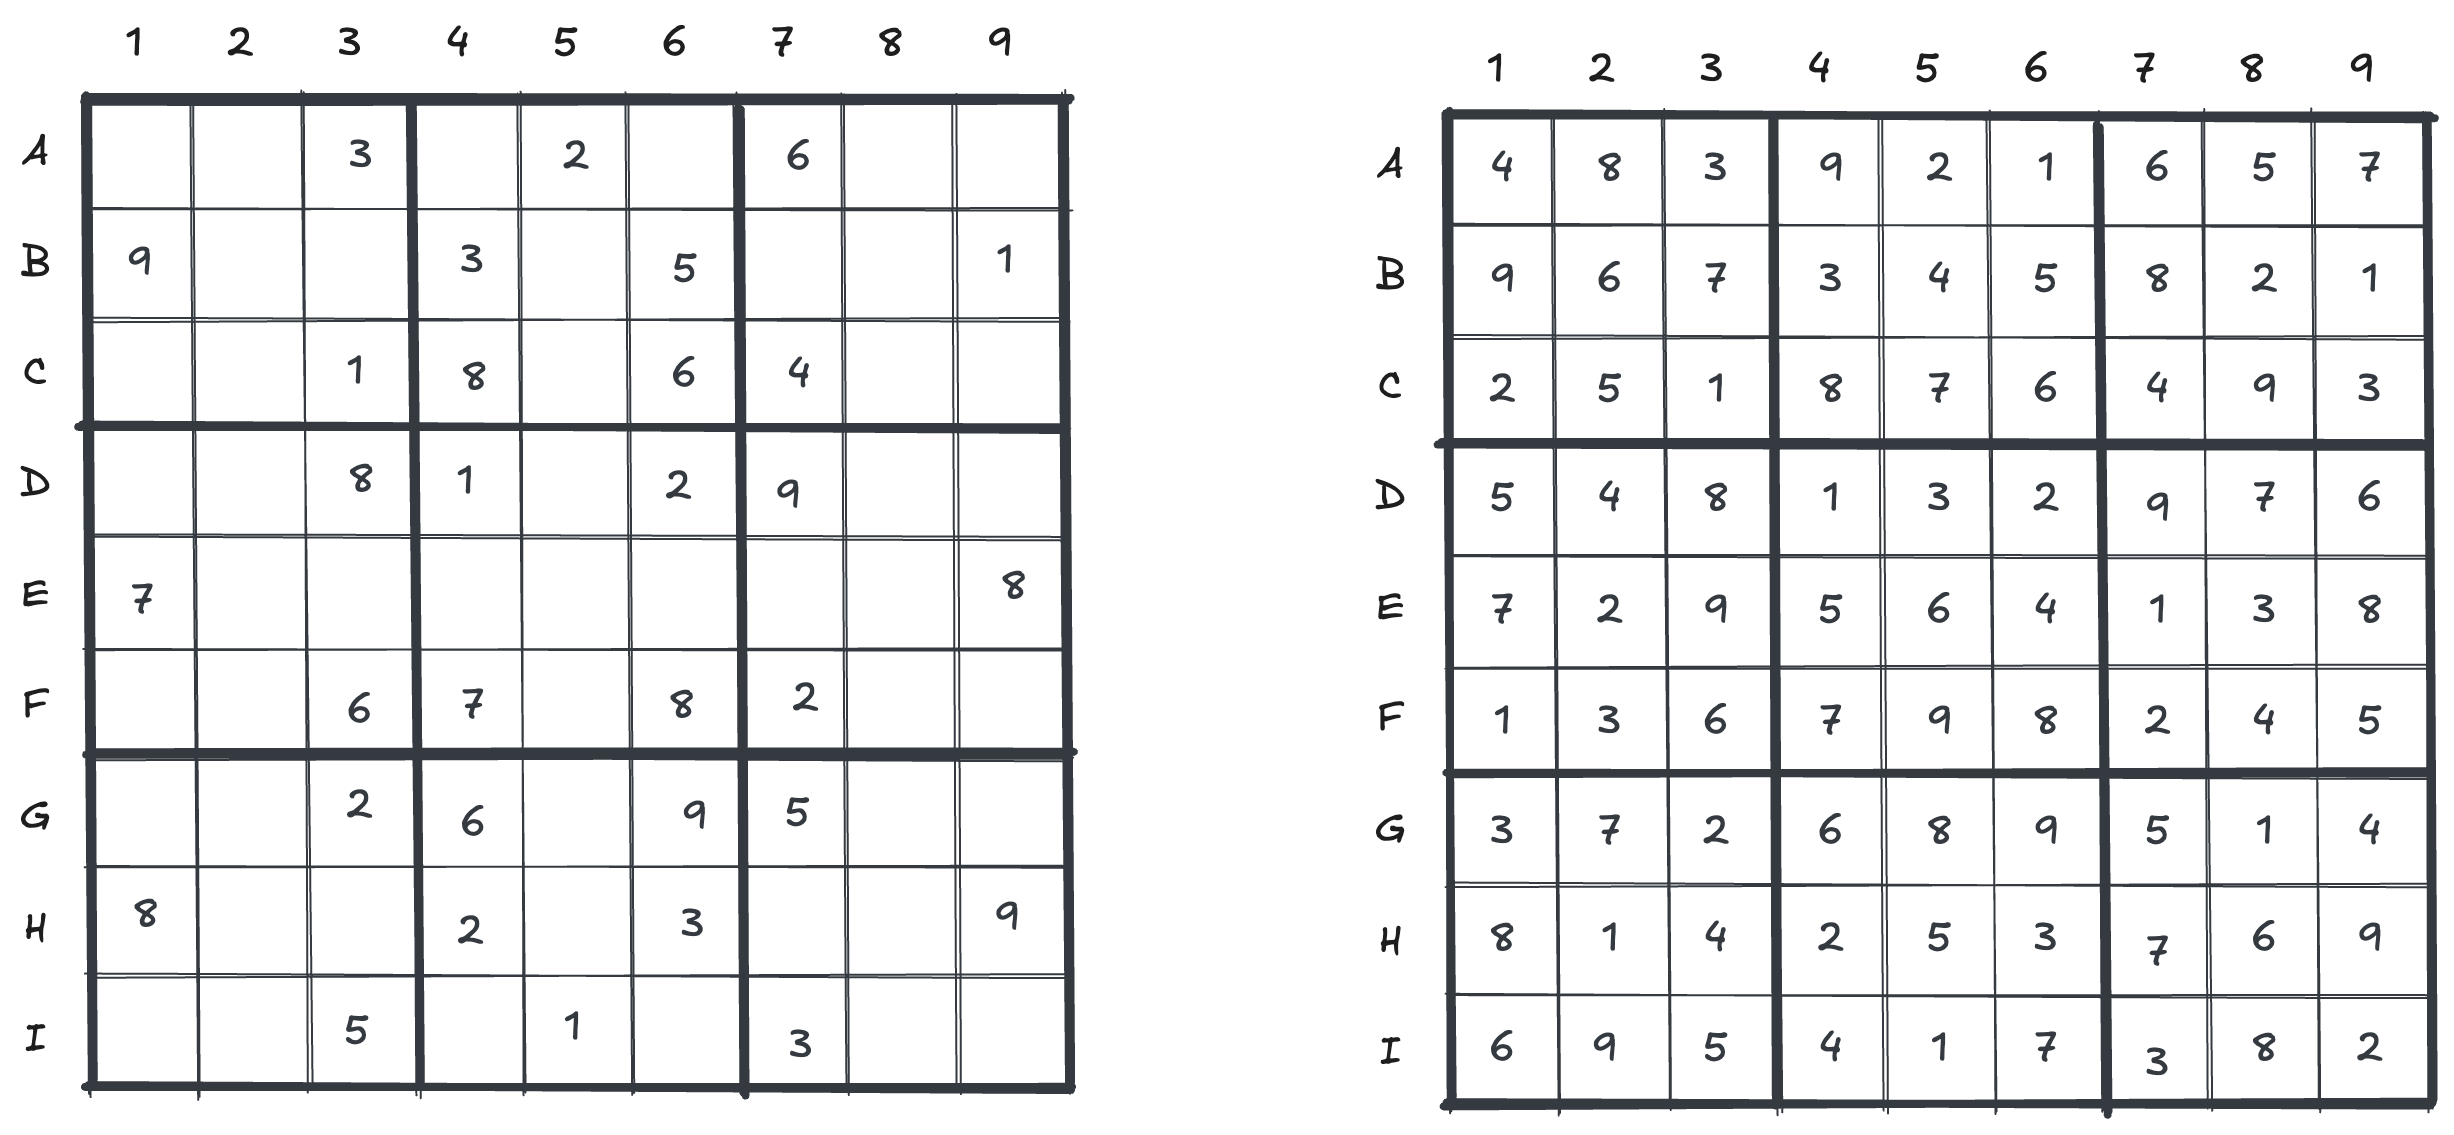

In [105]:
grid = [
    [0, 0, 3, 0, 2, 0, 6, 0, 0],
    [9, 0, 0, 3, 0, 5, 0, 0, 1],
    [0, 0, 1, 8, 0, 6, 4, 0, 0],
    [0, 0, 8, 1, 0, 2, 9, 0, 0],
    [7, 0, 0, 0, 0, 0, 0, 0, 8],
    [0, 0, 6, 7, 0, 8, 2, 0, 0],
    [0, 0, 2, 6, 0, 9, 5, 0, 0],
    [8, 0, 0, 2, 0, 3, 0, 0, 9],
    [0, 0, 5, 0, 1, 0, 3, 0, 0]
]

To describe Sudoku using the given CSP class, we can define the variables as the 81 square:

In [106]:
variables = [f'{row}{col}' for row in 'ABCDEFGHI' for col in '123456789']

The empty squares have the domain:

$\displaystyle D_i = \{1,2,3,4,5,6,7,8,9\}$

and the pre-filled squares have a domain consisting of a single value.

In [107]:
def create_sudoku_domain(grid):
    domains = {}
    assignment = {}
    for row in 'ABCDEFGHI':
        for col in '123456789':
            var = f'{row}{col}'
            value = grid[ord(row) - ord('A')][int(col) - 1]
        
            if value == 0:
                domains[var] = list(range(1, 10))
        
            else:
                domains[var] = [value]
                assignment[var] = value
    return domains, assignment

domains, assignment = create_sudoku_domain(grid)

In addition, there are 27 different Alldiff constraints, one for each unit (row, column, and box):

$\displaystyle C = \{ \\
\quad \text{Alldiff}(A_1, A_2, A_3, A_4, A_5, A_6, A_7, A_8, A_9), \\
\quad \text{Alldiff}(B_1, B_2, B_3, B_4, B_5, B_6, B_7, B_8, B_9), \\ 
\quad \text{Alldiff}(C_1, C_2, C_3, C_4, C_5, C_6, C_7, C_8, C_9), \\ 
\quad ... \\
\quad \text{Alldiff}(I_1, I_2, I_3, I_4, I_5, I_6, I_7, I_8, I_9) \\ 
\}$

We can implement the constraints expanding them into neigbors and a set of binary constraints:

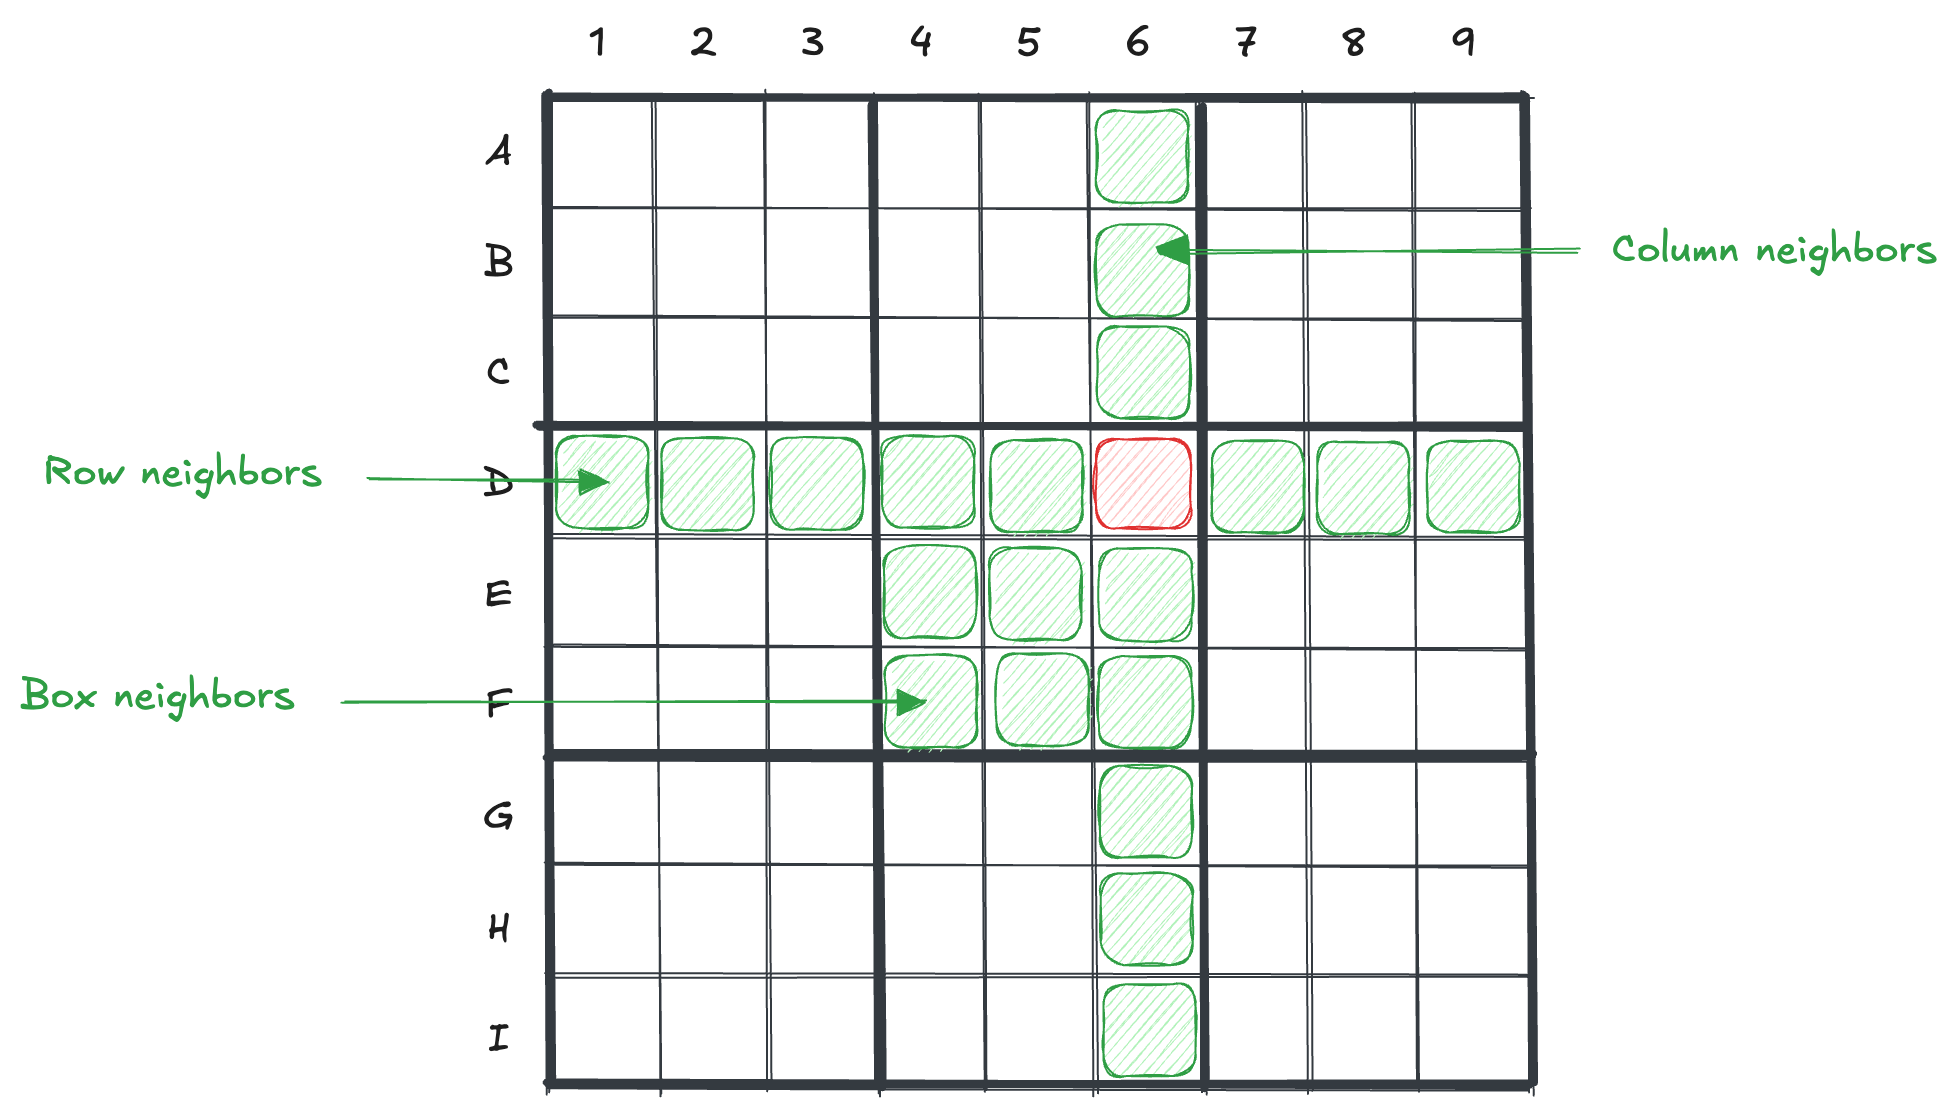

In [108]:
def create_sudoku_neighbors(variables):
    neighbors = {}

    for var in variables:
        neighbors[var] = []

        row, col = var[0], var[1]

        # Row neighbors
        for c in '123456789':
            neighbor = f'{row}{c}'
            if neighbor != var:
                neighbors[var].append(neighbor)

        # Column neighbors
        for r in 'ABCDEFGHI':
            neighbor = f'{r}{col}'
            if neighbor != var:
                neighbors[var].append(neighbor)

        # Box neighbors
        box_row_start = (ord(row) - ord('A')) // 3 * 3
        box_col_start = (int(col) - 1) // 3 * 3

        for r in range(box_row_start, box_row_start + 3):
            for c in range(box_col_start, box_col_start + 3):
                neighbor = f'{chr(r + ord('A'))}{c + 1}'
                if neighbor != var:
                    neighbors[var].append(neighbor)

        neighbors[var] = list(set(neighbors[var])) # remove duplicates

    return neighbors

neighbors = create_sudoku_neighbors(variables)

In [109]:
def sudoku_constraints(var_1, val_1, var_2, val_2):
    return val_1 != val_2

Before creating the CSP object, we can create a subclass in order to override the print() method to show the Sudoku board in a more readable way:

In [110]:
class SudokuCSP(CSP):
    def print(self, v=False, d=False, n=False, a=False, board=True):
        super().print(v, d, n, a)
        if board:
            print("Sudoku Board:")
            for row in 'ABCDEFGHI':
                if row in 'ADG':
                    print("------+-------+------")
                line = ""
                for col in '123456789':
                    if col in '47':
                        line += "| "
                    var = f'{row}{col}'
                    if var in self.assignment:
                        line += str(self.assignment[var]) + " "
                    else:
                        line += ". "
                print(line)
            print("------+-------+------")

We create the object and print the board:

In [111]:
sudoku = SudokuCSP(variables, domains, neighbors, sudoku_constraints, assignment)
sudoku.print()

Sudoku Board:
------+-------+------
. . 3 | . 2 . | 6 . . 
9 . . | 3 . 5 | . . 1 
. . 1 | 8 . 6 | 4 . . 
------+-------+------
. . 8 | 1 . 2 | 9 . . 
7 . . | . . . | . . 8 
. . 6 | 7 . 8 | 2 . . 
------+-------+------
. . 2 | 6 . 9 | 5 . . 
8 . . | 2 . 3 | . . 9 
. . 5 | . 1 . | 3 . . 
------+-------+------


## Constraint propagation

Unlike atomic state-space search, which progresses by expanding nodes, a CSP algorithm has the possibility to **propagate the constraints to limit the available actions** (it does not make sense to color two neighboring states with the same color in the coloring-map problem). Reducing the legal values of a variable based on constraints may further restrict other variables, simplifying future choices. This idea can be integrated with search or used as a preprocessing step, sometimes solving the problem entirely without search. The core idea is **local consistency**: treating variables as nodes and binary constraints as edges, enforcing consistency eliminates invalid values throughout the graph. We now explore different types of consistency.

### Node consistency

A variable is **node-consistent** if all values in its domain satisfy its unary constraints. For example, in a map-coloring problem, if South Australians dislike green, the domain {red, green, blue} becomes node-consistent by removing green, leaving {red, blue}. A graph is node-consistent if all its variables are node-consistent. It is easy to eliminate all the unary constraints in a CSP by reducing the domain of variables with unary constraints at the start of the solving process.

### Arc consistency

A variable is **arc-consistent** if every value in its domain satisfies the binary constraints involving that variable. More formally, a varibale is arc-consistent with respect to another variable if for every value in its domain there is some value in the domain of the other variable that satisfies the binary constraint on the arc between the two variable. For example, consider the following two variables:

$\displaystyle X_1, \quad D_{X_1} = \{0,1,2,3,4,5,6,7,8,9\}$

$\displaystyle X_2, \quad D_{X_2} = \{0,1,2,3,4,5,6,7,8,9\}$

and the following constraint:

$\displaystyle C = <(X_1, X_2), \quad X_2 = X_1^2>$

which can be writeen explicitly as

$\displaystyle C = < (X_1, X_2), \{(0,0), (1,1), (2,4), (3,9) \}$

To make the first variable arc-consistent with respect to the second one, we can reduce its domain to:

$\displaystyle D_{X_1} = \{0,1,2,3\}$

We can write it in Python as:

In [112]:
def make_arc_consistent(csp, var_i, var_j):
    # Flag to check if the domain of var_i has been revised
    revised = False

    # For each value in the domain of var_i
    for val_i in csp.domains[var_i][:]:  
            
            # Check if there is a value in the domain of var_j that satisfies the constraint
            if not any(csp.constraints(var_i, val_i, var_j, val_j) for val_j in csp.domains[var_j]):

                # If not, remove the value from the domain of var_i
                csp.domains[var_i].remove(val_i)
                
                # Set the flag to True
                revised = True
    # Return the flag
    return revised

We can apply this to the example:

In [113]:
# Define the variables
variables = ['X1', 'X2']

# Define the domains
domains = {
    'X1': [0, 1, 2, 3, 4, 5, 6, 7, 8, 9],
    'X2': [0, 1, 2, 3, 4, 5, 6, 7, 8, 9]
}

# Define the neighbors
neighbors = {
    'X1': ['X2'],
    'X2': ['X1']
}

# Define the constraints as a function
def constraints(var_1, val_1, var_2, val_2):
    if var_1 == 'X1':
        allowed_pairs = [(0, 0), (1, 1), (2, 4), (3, 9)]
        return (val_1, val_2) in allowed_pairs
    elif var_1 == 'X2':
        allowed_pairs = [(0, 0), (1, 1), (4, 2), (9, 3)]
        return (val_1, val_2) in allowed_pairs

# Create the CSP instance
csp = CSP(variables, domains, neighbors, constraints, {})

We can check the initial domains of the two variables:

In [114]:
print("Updated domain of X1:", csp.domains['X1'])
print("Updated domain of X2:", csp.domains['X2'])

Updated domain of X1: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9]
Updated domain of X2: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9]


Now we can apply arc consistency to make X1 consistent with respect to X2 and check the new domain:

In [115]:
make_arc_consistent(csp, 'X1', 'X2')
print("Updated domain of X1:", csp.domains['X1'])

Updated domain of X1: [0, 1, 2, 3]


If we also make the second variable arc-consistent with respect to the first, then its domain becomes 

$\displaystyle D_{X_2} = \{0,1,4,9\}$

In [116]:
make_arc_consistent(csp, 'X2', 'X1')
print("Updated domain of X2:", csp.domains['X2'])

Updated domain of X2: [0, 1, 4, 9]


A graph is arc-consistent if every variable is arc-consistent with every other variable. Arc consistency is a powerful tool for **reducing the search space**, but it is not enough to solve a CSP. It is a necessary but not sufficient condition for a CSP to be solved.

### AC-3 algorithm

The most popular algorithm for enforcing arc consistency is called [**AC-3**](./papers/(1977)%20-%20Consistency%20in%20networks%20of%20relations.pdf). 

The algorithm maintains a queue of arcs to process, initially containing all arcs (each binary constraint generates two arcs, one per direction). It repeatedly pops an arbitrary arc, and makes the first variable of the arc consistent with the second. If the domain of the variable remains unchanged, it moves to the next arc. Otherwise, it adds all arcs ending in the revised variable to the queue, since reducing that domain may further restrict the domains of connected variables. If any domain becomes empty, the algorithm detects the inconsistency and returns failure. Otherwise, it continues until the queue is empty, leaving a problem equivalent to the original one but with smaller domains, making subsequent search more efficient. We can implement the AC-3 algorithm in Python as follows:

In [117]:
def AC3(csp):    
    
    # Initialize queue with all arcs in csp 
    queue = [(var_i, var_j) for var_i in csp.variables for var_j in csp.neighbors[var_i]]
    
    # Loop until queue is empty
    while queue:

        # Get first element in queue 
        var_i, var_j = queue.pop(0)

        # Makes var_i consistent with var_j
        if make_arc_consistent(csp, var_i, var_j):

            # If domain of var_i is empty, return False
            if not csp.domains[var_i]:
                return False

            # If the domain of var_i is one, assign the value to var_i
            if len(csp.domains[var_i]) == 1:
                csp.assign(var_i, csp.domains[var_i][0])
            
            # Add all neighbors of var_i to queue    
            for var_k in csp.neighbors[var_i]:
                if var_k != var_j:
                    queue.append((var_k, var_i))
    
    # Here, all arcs have been checked and the CSP is arc-consistent
    return True

For example, we can apply this algorithm to the map-coloring problem of Australia, defining an intial decision about the color of some territories:

In [119]:
import copy

australia_test = copy.deepcopy(australia)

australia_test.domains['WA'] = ['r']
australia_test.print(d=True)

Domains:
	WA: ['r']
	NT: ['r', 'g', 'b']
	Q: ['r', 'g', 'b']
	NSW: ['r', 'g', 'b']
	V: ['r', 'g', 'b']
	SA: ['r', 'g', 'b']
	T: ['r', 'g', 'b']


In [120]:
print("Result: ", AC3(australia_test))
australia_test.print(d=True)


Result:  True
Domains:
	WA: ['r']
	NT: ['g', 'b']
	Q: ['r', 'g', 'b']
	NSW: ['r', 'g', 'b']
	V: ['r', 'g', 'b']
	SA: ['g', 'b']
	T: ['r', 'g', 'b']


AC-3 successfully reduces the domains of the neighboring regions based on the constraints between them, ensuring that no adjacent regions can have the same color. The result shows a more restricted set of valid color assignments for some regions while others remain unaffected. In some cases, AC-3 can solve the problem completely by reducing every domain to size 1 and in others it proves that no solution exists by reducing some domain to size 0. For example if in the Australia example we force an impossible condition, like assigning the same color to two adjacent regions, the algorithm will return False:

In [121]:
australia_test.domains['NT'] = ['r']

print("Result: ", AC3(australia_test))
australia_test.print(d=True)

Result:  False
Domains:
	WA: []
	NT: ['r']
	Q: ['r', 'g', 'b']
	NSW: ['r', 'g', 'b']
	V: ['r', 'g', 'b']
	SA: ['g', 'b']
	T: ['r', 'g', 'b']


The AC-3 algorithm can be applied to Sudoku. For example, considering variable E6, constraints from its box remove {1, 2, 7, 8} from its domain, while column constraints eliminate {5, 6, 2, 8, 9, 3}, leaving E6 with a single possible value: {4}. Similarly, for I6, applying arc consistency to its column removes {5, 6, 2, 4 (due to E6), 8, 9, 3}, and consistency with I5 eliminates 1, leaving only {7}. The inference process continues in this manner:

In [122]:
AC3(sudoku)
sudoku.print()

Sudoku Board:
------+-------+------
4 8 3 | 9 2 1 | 6 5 7 
9 6 7 | 3 4 5 | 8 2 1 
2 5 1 | 8 7 6 | 4 9 3 
------+-------+------
5 4 8 | 1 3 2 | 9 7 6 
7 2 9 | 5 6 4 | 1 3 8 
1 3 6 | 7 9 8 | 2 4 5 
------+-------+------
3 7 2 | 6 8 9 | 5 1 4 
8 1 4 | 2 5 3 | 7 6 9 
6 9 5 | 4 1 7 | 3 8 2 
------+-------+------


Eventually, AC-3 can solve the entire puzzle (all the variables have their domains reduced to a single value). However, if every puzzle were solvable this way, Sudoku would lose its challenge. In practice, AC-3 only works for the easiest puzzles.

The algorithm's complexity can be analyzed as follows. In a CSP with n variables (each with a domain of at most d) and c binary constraints, each arc enters the queue at most d times, as its end variable has at most d values to remove. Since checking an arc consistency takes 

$\displaystyle O(d^2)$

the worst-case complexity is:

$\displaystyle O(cd^3)$

### Path consistency

We can further introduce **path consistency** to refine the search space beyond arc consistency, ensuring that constraints between variable pairs remain valid in the presence of a third variable. A two-variable set 

$\displaystyle \{X_i,X_j\}$

is path-consistent with respect to a third variable 

$\displaystyle X_m$

if, for every assignment 

$\displaystyle {X_i = a,X_j=b}$ 

consistent with the constraints on the variables, there is an assignment 

$\displaystyle {X_m = c}$

that satisfies the constraints on 

$\displaystyle {X_i,X_m} \; \text{and} \; {X_m,X_j}$

The name refers to the overall consistency of the path from the the two variable with the third one in the middle. Let's analyze path consistency in coloring the Australia map with two colors. We make the set {WA, SA} path-consistent with respect to NT by listing its valid assignments: {WA=r, SA=b} and {WA=b, SA=r}. In both cases, NT cannot be assigned either color without conflicting with WA or SA. Since no valid choice remains for NT, both assignments are eliminated, leaving {WA, SA} without a valid solution and proving the problem has no solution.

### K-consistency

We can generalize the concept of consistency to **k-consistency**, where a set of k variables is consistent if, for any assignment to (k-1) variables, there exists a valid assignment for the k-th variable. Special cases include:  

- **1-consistency** (node consistency): ensures each variable satisfies its unary constraints.  
- **2-consistency** (arc consistency): ensures every value of one variable has a consistent value in a connected variable  
- **3-consistency** (path consistency): extends arc consistency by considering a third variable.  

A **strongly k-consistent** CSP is consistent at all levels down to 1. In an **n-consistent** CSP, we can solve the problem sequentially: choosing X1, then X2 (ensured by 2-consistency), then X_3 (by 3-consistency), and so on. Since each Xi requires checking at most d values, the total runtime is

$\displaystyle O(n^2d)$

However, constraint satisfaction remains NP-complete, and enforcing n-consistency is exponential in the worst case.

### Consistency checks for global constraints

Global constraints are common in real-world problems and can be efficiently handled by **special-purpose algorithms** rather than general methods.

The **Alldiff constraint** requires all involved variables to have distinct values. The inconsistency detection in that case works as follows: if there are m variables and n distinct values, and m>n, the constraint is unsatisfiable. The algorithm removes variables with singleton domains and eliminates their values from the domains of remaining variables. This process repeats until no singleton domains remain. If at any point a domain becomes empty or the number of variables exceeds available distinct values, inconsistency is detected.

Another important higher-order constraint is the **Atmost constraint**, it restricts the number of times a specific value can appear among a set of variables. Given a set of variables:

$\displaystyle X = \{X_1, X_2, ... ,X_n\}$

an AtMost constraint of the form 

$\displaystyle AtMost(k, v, X)$

ensures that the value v appears in at most k of these variables. This constraint is useful in scheduling and resource allocation problems, where a limit must be enforced on certain values. We can detect an inconsistency in that case if more than the maximum number of variables have already been assigned the value (overassignment).

### Bounds propagation

For large problems with integer values, such as logistical problems involving moving thousands of people in hundreds of vehicles, it is usually not possible to represent the domain of each variable as a large set of integers and gradually reduce that set by consistency-checking methods. Instead, domains are represented by upper and lower bounds and are managed by **bounds propagation**. For example, in an airline scheduling problem, let’s suppose there are two flights

$\displaystyle F_1, F_2$

for which the planes have capacities 165 and 385, respectively. The initial domains for the numbers of passengers on the flights are then 

$\displaystyle D_1 = [0, 165]$

$\displaystyle D_2 = [0, 385]$

Now suppose we have the additional constraint that the two flights together must carry 420 people: 

$\displaystyle C = <(F_1, F_2), \quad F_1 + F_2 = 420>$

Propagating bounds constraints, we reduce the domains to 

$\displaystyle D_1 = [35, 165]$

$\displaystyle D_2 = [255, 385]$

We say that a CSP is **bounds-consistent** if for every variable X, and for both the lower-bound and upper-bound values of its domain, there exists some value of Y that satisfies the constraint between X and Y, for every variable Y. This kind of bounds propagation is widely used in practical constraint problems.

## Backtracking Search

After applying constraint propagation, some variables may still have multiple possible values, meaning we haven't fully determined a solution. In such cases,** search is necessary** to find a valid assignment. An approach can be apply a depth-limited search algorithm, where each state represents a partial assignment of values to variables, and actions extend the assignment by choosing a value for an unassigned variable. For example, in the Australia map-coloring problem, an action could be assigning "NSW=r" or "SA=b". For a CSP with n variables, each having d possible values, the search tree consists of paths where complete assignments (valid or not) appear as leaf nodes at depth n. However, the tree’s structure reveals its complexity:

- at the root, any of the n variables can be assigned one of d values, leading to a branching factor of n·d.
- at the next level, the remaining (n-1) variables each have d choices, giving a branching factor of (n-1)·d.

This pattern continues until all variables are assigned. Thus, the total number of leaf nodes in the search tree is:

$\displaystyle n! \cdot d^n$

This is **much larger** than the number of possible assignments:

$\displaystyle d^n$

The extra factor of n! in the number of leaf nodes comes from the fact that, without any restrictions, the **search tree considers all possible orders in which variables could be assigned values**. However, in CSPs, this leads to **redundant paths** because of a property called **commutativity**. A problem is commutative if the **order** in which we apply a given set of actions does not affect the outcome. In the context of CSPs, this means that assigning values to variables in different sequences does not create fundamentally different solutions. For example, in the Australia map-coloring problem, assigning:

1 - "NSW=r" and then "SA=b"

2 - "SA=b" and then "NSW=r"

leads to the same final assignment. These two paths in the search tree represent the same solution, yet both are initially considered separate in an unrestricted search tree. To eliminate redundancy, we **always assign one variable per level** in the search tree. Instead of branching on all possible variable-value pairs (e.g., choosing between "NSW=r" and "SA=b" at the root), we first pick a single variable (e.g., "SA") and then explore its possible values ("SA=r", "SA=g", "SA=b"). This eliminates unnecessary permutations in the order of assignments. With this restriction:

- the first decision is which value to assign to a specific variable (e.g., "SA=r").
- the next decision is which value to assign to the next unassigned variable (e.g., "NSW=g").
- this continues until all variables are assigned

Since we are **no longer considering different orderings of assignments**, we remove the n! factor, reducing the number of leaves to the actual number of complete assignments. Additionally, once a variable is assigned, we never **backtrack** over the choice of which variable to assign next, simplifying the search.

We can consider a simple backtracking algorithm: it repeatedly chooses an unassigned variable, and then tries all values in the domain of that variable in turn, trying to extend each one into a solution via a recursive call. If the call succeeds, the solution is returned, and if it fails, the assignment is restored to the previous state, and we try the next value. For example, in the map-coloring problem, where we have assigned variables in the order WA, NT,Q is showed in the following figure:  

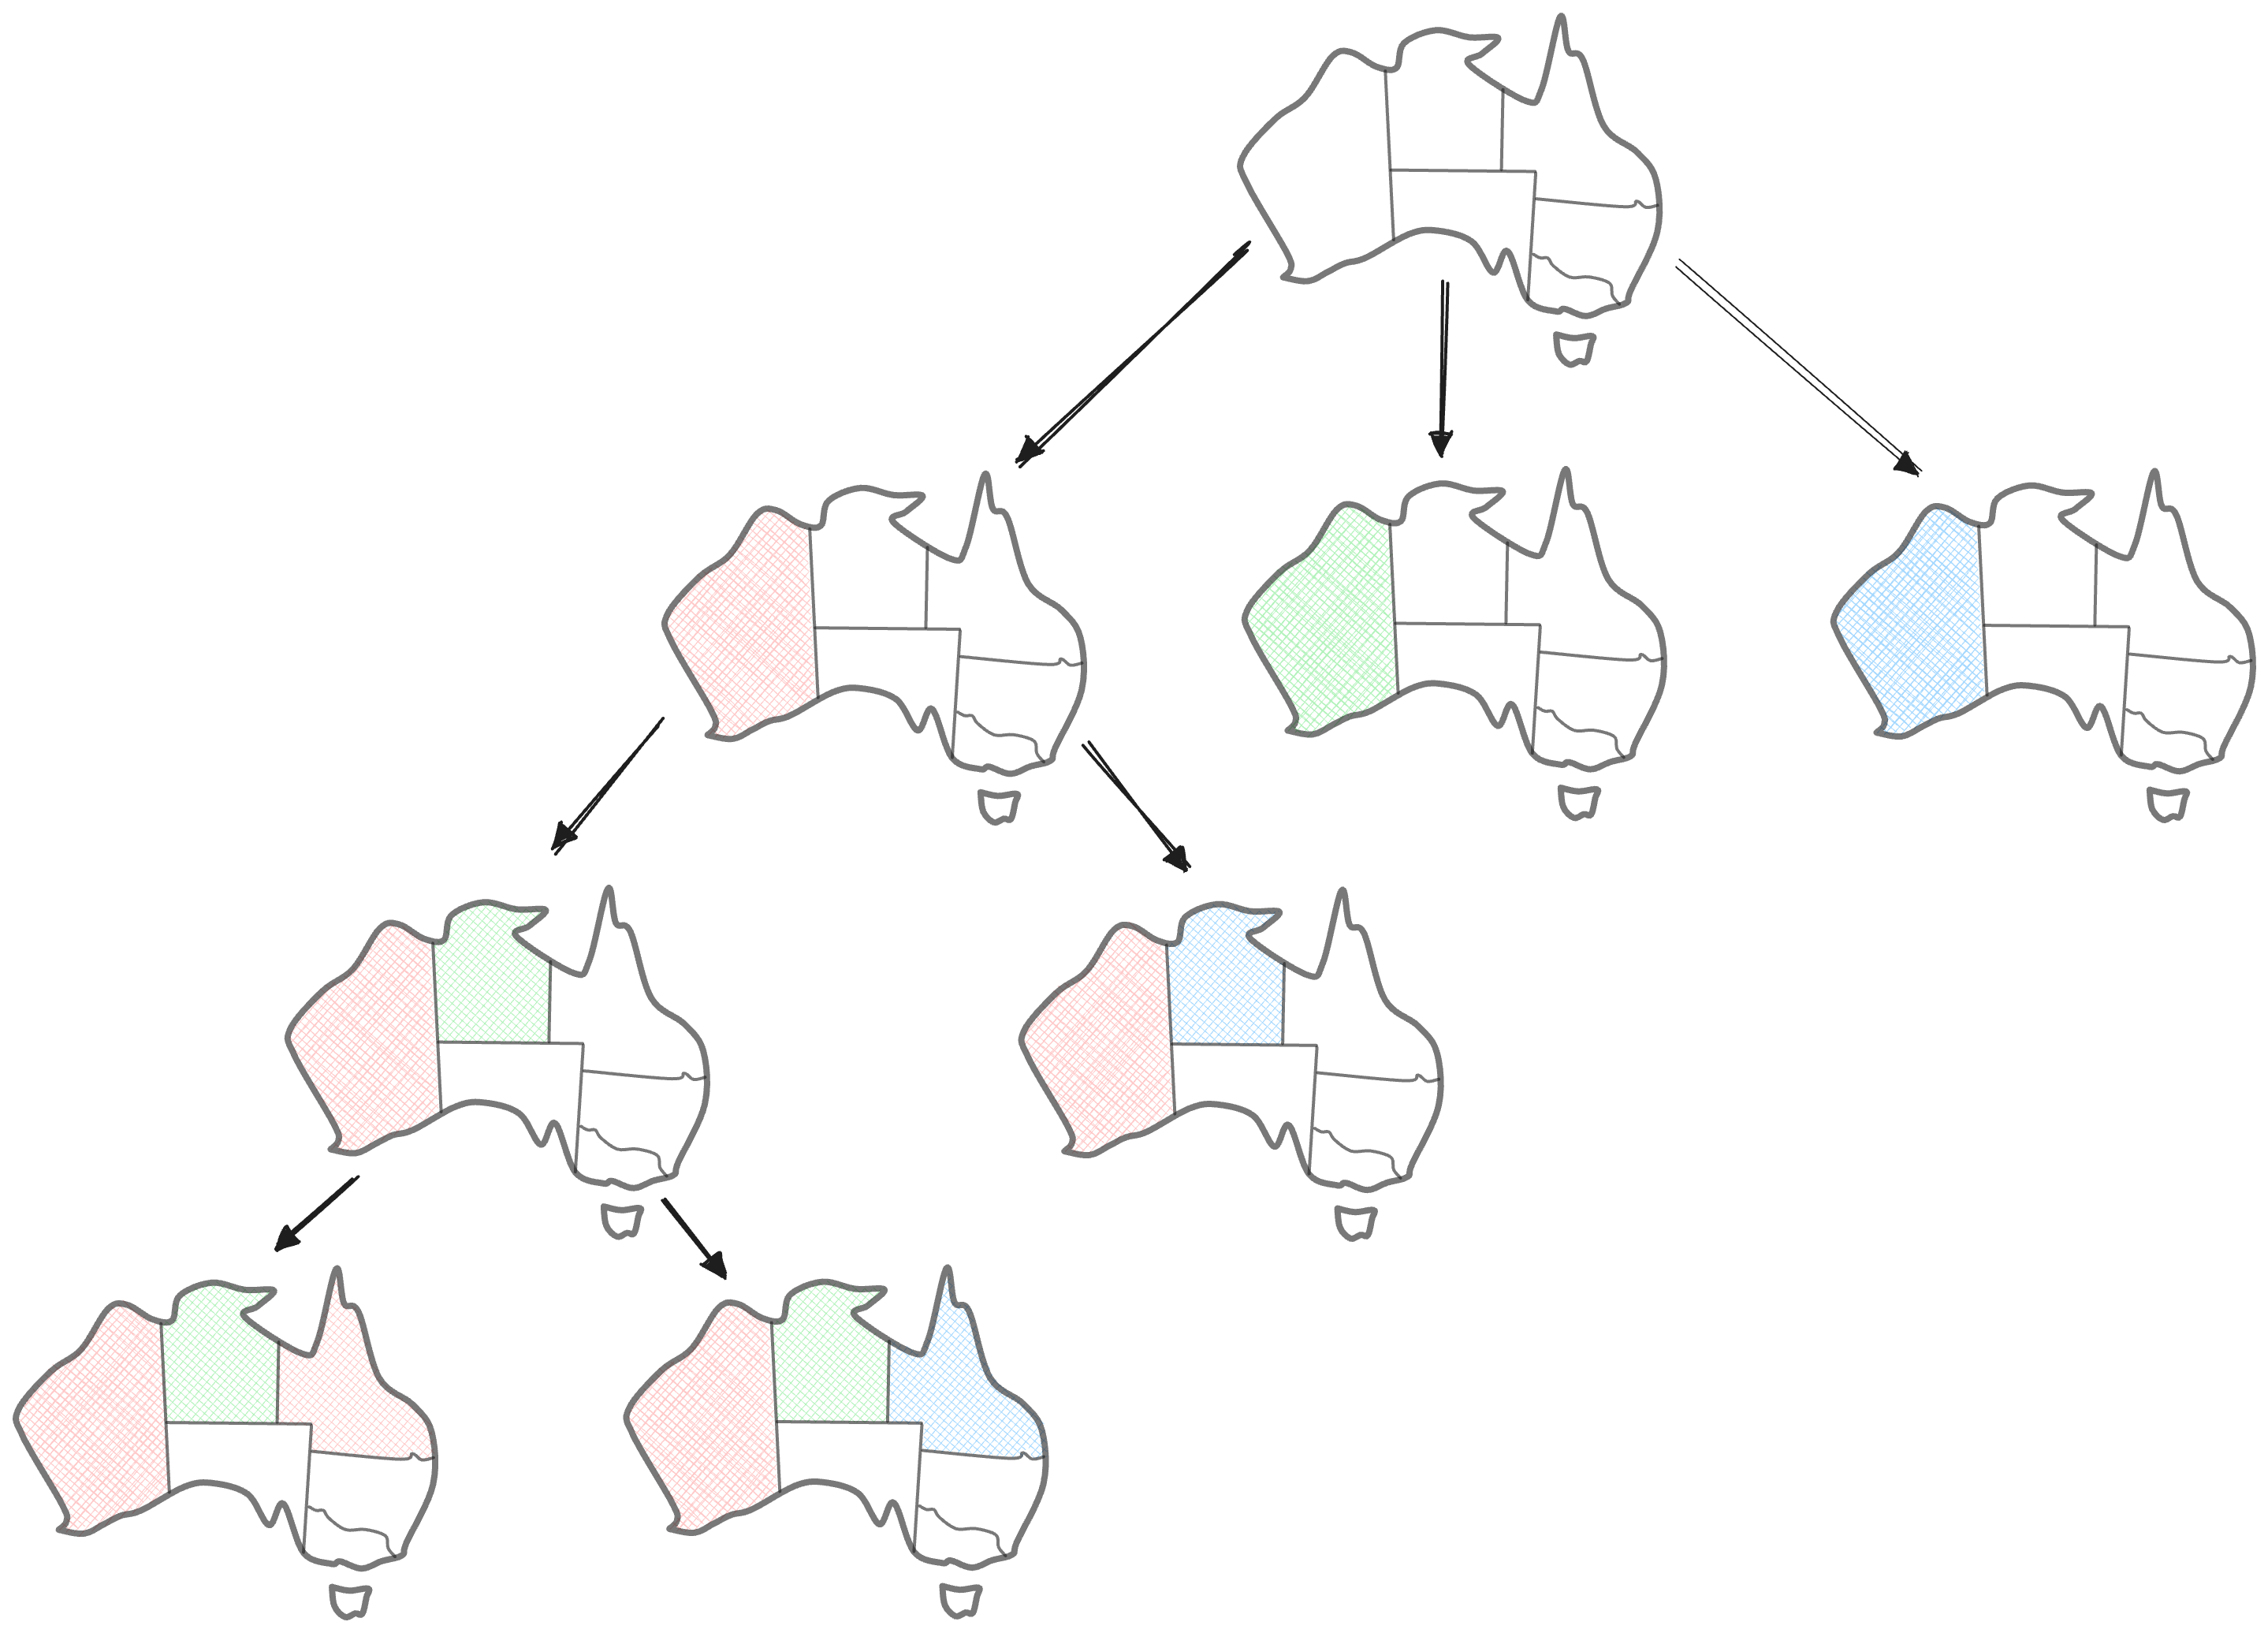

The algorithm can be implemented in Python as follows:

In [148]:
def backtrack(csp, select_unassigned_variable, order_domain_values, inference):

    # Select an unassigned variable
    var = select_unassigned_variable(csp)

    print(var)
    
    # For each value in the domain of the variable
    for value in order_domain_values(csp, var):

        # Check if the value is consistent with the assignment
        if csp.count_conflicts(var, value) == 0:
            
            # In case the value is consistent, assign it
            csp.assign(var, value)
            
            # Perform inference (e.g. arc consistency)
            inferences = inference(csp, var, value)

            # If the inferences are consistent
            if all(inferences[neighbor] for neighbor in inferences):  
                
                # Recursively call backtrack
                result = backtrack(csp) 
                
                # If the result is not failure, return the result
                if result:
                    return result

            # Here, the inferences were not consistent, so unassign the variable
            csp.unassign(var)
        
    return None

This general approach must be defined in detail by deciding **which variable to assign**, choosing the right variable can greatly impact efficiency, and **in what order to try its values**, some orderings may lead to faster solutions by reducing backtracking. Additionally, we need to determine **which inferences to apply** at each step (arc-consistency, path-consistency, or k-consistency), since constraints can be used to prune the search space early, preventing unnecessary work. By optimizing these aspects, backtracking can be made significantly more efficient. Whereas the uninformed search algorithms could be improved only by supplying them with domain-specific heuristics, it turns out that backtracking search can be improved using **domain-independent heuristics** that take advantage of the factored representation of CSPs. For the first implementation, we can introduce these methods in a straightforward way:

In [149]:
def  first_unassigned_variable(csp):
    # Return the first unassigned variable
    return next(var for var in csp.variables if var not in csp.assignment)

In [150]:
def unordered_domain_values(csp, var):
    # Return the list of values in the domain of the given variable
    return list(csp.domains[var])

In [151]:
australia_test = copy.deepcopy(australia)

backtrack(australia_test, first_unassigned_variable, unordered_domain_values, AC3)

StopIteration: 

In [129]:
australia_test.print(d=True, a=True)

australia_test.domains['WA']

Domains:
	WA: ['r', 'g', 'b']
	NT: ['r', 'g', 'b']
	Q: ['r', 'g', 'b']
	NSW: ['r', 'g', 'b']
	V: ['r', 'g', 'b']
	SA: ['r', 'g', 'b']
	T: ['r', 'g', 'b']
Assignment: {'WA': 'r', 'NT': 'g', 'Q': 'b', 'NSW': 'r', 'V': 'g', 'SA': 'b', 'T': 'r'}


['r', 'g', 'b']